# Identifying the satellites behind HETDEX PDR1 streaks

Interactive driver for the matching pipeline. Heavy lifting lives in importable
modules so it stays unit-tested and fixes can be handed back as single cells:

| module | role |
|---|---|
| `satstreak_core.py` | geometry, illumination, scoring (pure numpy, 72 unit tests) |
| `fetch_tles.py` | Space-Track `gp_history` downloader + cache |
| `match_streaks.py` | SGP4 + astropy frames, the matcher, diagnostics |
| `satstreak_plots.py` | ApJL-style figures |

`%autoreload 2` is on, so edits to any of those take effect on the next cell run.

Requires `pip install sgp4 joblib`.

## 0. Configuration

In [3]:
%load_ext autoreload
%autoreload 2

import os, sys, time
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, hstack

sys.path.insert(0, os.path.abspath("."))
import satstreak_core as core
import satstreak_plots as P
import fetch_tles as F
import match_streaks as M
from satstreak_core import MatchConfig

# Input catalog lives one level up; everything this notebook writes stays
# beside the notebook so the data directory is not polluted.
CATALOG    = "../intermediate/HETDEX_PDR1_sats.fits"
CACHE_DIR  = "tle_cache"
TRIAL_OUT  = "trial_matched.fits"
OUT        = "HETDEX_PDR1_sats_matched.fits"
JOINED_OUT = "HETDEX_PDR1_sats_with_ids.fits"

assert os.path.exists(CATALOG), f"catalog not found: {os.path.abspath(CATALOG)}"
print("catalog:", os.path.abspath(CATALOG))
print("cache  :", os.path.abspath(CACHE_DIR))

P.PLOT_DIR = "trend_plots/"
P.apjl_style()

site = M.read_site(CATALOG)
print("HET site (lat, lon, elev):", site)
assert 30 < site[0] < 31 and -105 < site[1] < -103, \
    "site looks transposed: expect (30.68, -104.01, 2026)"
print("site orientation OK  (lat positive, lon negative)")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
catalog: /home/jovyan/work/pdr1/claude-tests/satellites/hetdex_sats/intermediate/HETDEX_PDR1_sats.fits
cache  : /home/jovyan/work/pdr1/claude-tests/satellites/hetdex_sats/crossmatch/tle_cache
HET site (lat, lon, elev): (30.681436, -104.014744, 2026.0)
site orientation OK  (lat positive, lon negative)


A transposed site would still propagate and produce entirely plausible tracks
that never match anything, so it is worth the assert.

## 0b. Unit tests — 72 assertions, ~1 s, no network

In [4]:
# run in-process rather than via ! so output appears here immediately
import test_geometry, importlib
importlib.reload(test_geometry)
for fn in [f for n, f in vars(test_geometry).items()
           if n.startswith("test_") and callable(f)]:
    fn()
print("\nFAILURES:", test_geometry.FAILURES or "none")

PASS  radec roundtrip RA: got 0.0 want 0.0 (tol 1e-09)
PASS  radec roundtrip Dec: got 0.0 want 0.0 (tol 1e-09)
PASS  angsep 90 deg: got 90.0 want 90.0 (tol 1e-09)
PASS  angsep pole: got 90.0 want 90.0 (tol 1e-09)
PASS  angsep 1 arcsec: got 1.0 want 1.0 (tol 1e-06)
PASS  angsep cos(dec): got 0.499995 want 0.5 (tol 0.001)
PASS  PA north: got 0.0 want 0.0 (tol 1e-06)
PASS  PA east: got 90.0 want 90.0 (tol 1e-06)
PASS  PA south: got 180.0 want 180.0 (tol 1e-06)
PASS  PA west: got 270.0 want 270.0 (tol 1e-06)
PASS  PA at dec=60 tilts east of the dec=0 value
PASS  dPA 179 vs 1: got 2.0 want 2.0 (tol 1e-09)
PASS  dPA 10 vs 100: got 90.0 want 90.0 (tol 1e-09)
PASS  dPA 350 vs 170: got 0.0 want 0.0 (tol 1e-09)
PASS  dPA 45 vs 225: got 0.0 want 0.0 (tol 1e-09)
PASS  equator pole is +z: got [0. 0. 1.] want [0 0 1] (tol 1e-12)
PASS  perp 5 deg: got 5.0 want 5.0 (tol 1e-09)
PASS  perp on-circle: got 0.0 want 0.0 (tol 1e-12)
PASS  midpoint RA: got 15.0 want 15.0 (tol 1e-09)
PASS  midpoint Dec: got 0

## 1. The catalog

**527 streaks / 492 shots** (the README says 533 / 497; `streak_id` runs 0-526
with no gaps, so nothing is missing from the file — the README predates this
extraction).

Two things now settled:

* **`mjd_shot` is the start of a 22-minute shot.** The window is
  `[mjd_shot - 60 s, mjd_shot + 1320 s + 60 s]`, set by
  `exposure_span_s = 1320.0`. `exptime` (366.9-728.0 s) is the per-dither value
  and cannot be used to reconstruct the span.
* **`streak_pa` is already a proper spherical PA.** I had warned it would differ
  from a spherical PA at high declination; measured against the data, the median
  difference is 0.000 deg and the maximum 0.020 deg. That warning was wrong and
  is withdrawn — no convention juggling needed.

In [5]:
info = Table.read(CATALOG, hdu="INFO")
print(f"{len(info)} streaks across {len(set(info['shotid'].tolist()))} shots")

# streak epoch distribution -- why later nights are the better test
yr = np.array([1858 + (m + 321) / 365.25 for m in info["mjd_shot"]]).astype(int)
for y in np.unique(yr):
    print(f"  {y}: {(yr == y).sum():3d} streaks")

# endpoint self-consistency (this is what told us the catalog is sound)
A = core.radec_to_unit(info["ra_start"], info["dec_start"])
B = core.radec_to_unit(info["ra_end"], info["dec_end"])
sep = core.angsep(A, B) * 3600.0
print(f"\nendpoint separation / seg_len_arcsec: "
      f"median {np.median(sep / info['seg_len_arcsec']):.4f}")
dpa = core.pa_difference(core.position_angle(core.midpoint(A, B), B) % 180.0,
                         info["streak_pa"])
print(f"spherical PA vs streak_pa: median {np.median(dpa):.4f} deg, "
      f"max {dpa.max():.4f} deg")

527 streaks across 492 shots
  2017:   4 streaks
  2018:  24 streaks
  2019:  47 streaks
  2020:  63 streaks
  2021:  90 streaks
  2022: 124 streaks
  2023: 112 streaks
  2024:  63 streaks

endpoint separation / seg_len_arcsec: median 1.0000
spherical PA vs streak_pa: median 0.0004 deg, max 0.0199 deg


In [6]:
len( set( [ int(shotid/1000) for shotid in np.unique( info['shotid'])]))

370

## 1b. TLE cache coverage — check this before reading any match rate

A night with no cached element sets is invisible in the results: its streaks
come back unmatched, which looks identical to "no satellite found". This cell
says how much of the survey is actually searchable.

In [7]:
coverage = M.cache_coverage(info, CACHE_DIR)

observing nights needed : 370
  cached   :  370   2017-03-22 .. 2024-07-31
  complete: every night has cached elements


### 1b.ii TLE cache content audit

`cache_coverage` above only checks whether each night's file **exists**.
Two failure modes are invisible to it:

| Failure | Symptom | Cause |
|---|---|---|
| Partial download | File exists but is small | Network error mid-fetch |
| Object-level gap | File complete, but a specific NORAD absent | Space-Track didn't publish a TLE for that object on that night |

`audit_tle_cache` counts objects in every file and flags nights below 70% of
the median — a reliable sign of truncation.  `audit_tle_age` shows how stale
the TLEs were for the matched streaks; a large `|tle_age_hours|` means the
propagator was extrapolating far from the element-set epoch, degrading accuracy.

In [8]:
import importlib; importlib.reload(M)

# --- 1. File-size check (fast, catches partial downloads instantly)
#        full_scan=True decompresses every file for an exact object count;
#        use it to confirm a suspect night identified here.
cache_audit = M.audit_tle_cache(CACHE_DIR)

# --- 2. TLE age for matched streaks (catches object-level gaps in coverage)
if os.path.exists(OUT):
    _match_tmp = Table.read(OUT, hdu="MATCH")
    print()
    M.audit_tle_age(_match_tmp)
else:
    print("\n(run section 5 first to see TLE age statistics for matched streaks)")

370 cached nights, 1326.5 MB total, median 3594.8 KB/night
  7 nights flagged on file size (< 2000 B or < 50% of median):
    60146  gp_60146_2023-07-22.3le.gz  645.1 KB
    57833  gp_57833_2017-03-22.3le.gz  1305.2 KB
    60145  gp_60145_2023-07-21.3le.gz  1457.4 KB
    58705  gp_58705_2019-08-11.3le.gz  1502.3 KB
    58992  gp_58992_2020-05-24.3le.gz  1554.8 KB
    60148  gp_60148_2023-07-24.3le.gz  1687.0 KB
    60136  gp_60136_2023-07-12.3le.gz  1770.1 KB

(run section 5 first to see TLE age statistics for matched streaks)


In [9]:
# Delete corrupt/partial TLE files so the fetcher treats them as missing,
# then re-fetch them from Space-Track.
#
# The fetcher skips any file with size > 0, so corrupt small files must be
# removed first.  Set DRY_RUN = False when ready to actually delete and fetch.

DRY_RUN = True
suspect_nids = cache_audit.get("suspect_nights", [])
night_files  = M.find_night_files(CACHE_DIR)

to_delete = [(nid, night_files[nid]) for nid in suspect_nids if nid in night_files]
print(f"{len(to_delete)} files to delete{'  (DRY RUN)' if DRY_RUN else ''}:")
for nid, path in to_delete:
    sz = path.stat().st_size / 1e6
    print(f"  {path.name}  ({sz:.2f} MB)")

if not DRY_RUN:
    for nid, path in to_delete:
        path.unlink()
        print(f"  deleted {path.name}")
    print(f"\nDeleted {len(to_delete)} files — re-fetching from Space-Track ...")
    F.main(["--catalog", CATALOG, "--cache-dir", CACHE_DIR])
    # Refresh the audit so the notebook reflects the new state
    cache_audit = M.audit_tle_cache(CACHE_DIR)
    coverage    = M.cache_coverage(info, CACHE_DIR)
else:
    print("\nSet DRY_RUN = False to delete and re-fetch.")

7 files to delete  (DRY RUN):
  gp_57833_2017-03-22.3le.gz  (1.31 MB)
  gp_58705_2019-08-11.3le.gz  (1.50 MB)
  gp_58992_2020-05-24.3le.gz  (1.55 MB)
  gp_60136_2023-07-12.3le.gz  (1.77 MB)
  gp_60145_2023-07-21.3le.gz  (1.46 MB)
  gp_60146_2023-07-22.3le.gz  (0.65 MB)
  gp_60148_2023-07-24.3le.gz  (1.69 MB)

Set DRY_RUN = False to delete and re-fetch.


## 2. Fetch archival TLEs

`fetch_tles` skips nights already on disk, so this is safe to re-run — it only
downloads what is missing and costs nothing when the cache is complete. Set
`FETCH_LIMIT` to cap a session; `None` fetches the whole gap.

In [10]:
FETCH_LIMIT = None      # e.g. 25 to fetch in chunks; None = everything missing

if coverage["n_missing"] == 0:
    print("cache complete - nothing to fetch")
else:
    argv = ["--catalog", CATALOG, "--cache-dir", CACHE_DIR]
    if FETCH_LIMIT:
        argv += ["--max-nights", str(int(FETCH_LIMIT))]
    F.main(argv + ["--dry-run"])

cache complete - nothing to fetch


In [11]:
# the actual download; re-running is harmless, cached nights are skipped
if coverage["n_missing"]:
    argv = ["--catalog", CATALOG, "--cache-dir", CACHE_DIR]
    if FETCH_LIMIT:
        argv += ["--max-nights", str(int(FETCH_LIMIT))]
    F.main(argv)
    coverage = M.cache_coverage(info, CACHE_DIR)
else:
    print("cache complete - skipped")

cache complete - skipped


## 3. Match the nights you actually fetched

`cached_only=True` is essential here. `limit_nights=N` picks the *earliest* N
nights, which after a `--latest` fetch are exactly the ones with no TLE file —
every streak would return `n_propagated = 0` and look like a worse failure than
it is.

In [12]:
cfg = MatchConfig(
    coarse_radius_deg = 5.0,
    coarse_step_s     = 20.0,   # safe: the coarse threshold is rate-aware
    fine_step_s       = 0.5,
    max_perp_arcsec   = 900.0,
    max_pa_deg        = 6.0,
    exposure_span_s   = 1320.0, # 22 min shot, mjd_shot = start
    margin_before_s   = 60.0,
    margin_after_s    = 60.0,
    require_sunlit    = False,
    keep_n_candidates = 5,
)

# This is a SMOKE TEST, not the science run.  Capped at a few nights so it
# stays quick: with a full cache an uncapped "trial" re-matches every night and
# simply duplicates section 5, at ~5 s per night.
TRIAL_NIGHTS = 5
FORCE_TRIAL  = True

jobs = M.build_jobs(info, CACHE_DIR, cached_only=True, latest=True,
                    limit_nights=TRIAL_NIGHTS)
ids = [r["streak_id"] for _n, _p, gs in jobs for g in gs for r in g]
print(f"trial on {len(jobs)} of {coverage['n_cached']} cached nights "
      f"/ {len(ids)} streaks  (~{5*len(jobs):.0f} s)")

if M.output_is_current(TRIAL_OUT, CACHE_DIR, CATALOG, cfg=cfg) and not FORCE_TRIAL:
    trial = Table.read(TRIAL_OUT, hdu="MATCH")
    print(f"{TRIAL_OUT} is newer than the cache - loaded, not rematched")
else:
    print(f"satcat entries: {len(M.get_satcat(CACHE_DIR))}")
    t0 = time.time()
    results = M.run_all(jobs, site, cfg, CACHE_DIR, n_jobs=1)
    print(f"{time.time() - t0:.0f} s")
    trial = M.write_output(TRIAL_OUT, info, results, cfg, CATALOG)

sel = trial[np.isin(trial["streak_id"], ids)]
M.summarise(sel)

trial on 5 of 370 cached nights / 9 streaks  (~25 s)


satcat entries: 70217


  5/5 nights, 41s (8.1s/night)


41 s
matched 8/9 streaks (88.9%); 8 unambiguous
  median |perp| = 18.9"
  median |dPA|  = 0.08 deg
  crossing time rel. mjd_shot: median 569s, 16-84% 203 to 870s
  in umbra (impossible -> false positives): 0
          Cosmos: 4
           Other: 2
          OneWeb: 1
        Starlink: 1


## 3b. Triage

If the match count is zero, this says which stage failed. The three cases have
completely different causes, so read it before changing any parameter.

| symptom | meaning |
|---|---|
| `n_propagated == 0` | no element sets for that night — cache gap |
| `n_close == 0` | nothing near the field — window, site, or frames |
| `n_close > 0`, `n_candidates == 0` | near but failing the 900" / 6 deg cuts |

In [13]:
M.triage(sel)

9 streaks
  n_propagated == 0 : 0   (no TLEs loaded for the night)
  n_close      == 0 : 0   (nothing near the field -> window/site/frames)
  near but unscored : 1   (tolerances too tight, or wrong window)
  matched           : 8
  n_propagated   min  23818  median  24121  max  24218
  n_close        min     96  median    114  max    158
  n_candidates   min      0  median      1  max      2


streak_id,shotid,norad_id,object_name,object_id,object_type,country,launch_date,rcs_size,constellation,orbit_class,illum_label,match_perp_arcsec,match_sep_arcsec,match_pa_diff_deg,match_end_a_arcsec,match_end_b_arcsec,match_score,model_pa_deg,streak_pa_sph_deg,crossing_dt_s,tle_age_hours,range_km,sat_height_km,alt_deg,sun_alt_deg,phase_angle_deg,ang_rate_arcsec_s,ang_rate_deg_s,t_cross_s,g_mag_inst,g_mag_inst_550km,perigee_km,apogee_km,inclination_deg,eccentricity,period_min,second_score,score_margin,match_time_offset_s,crossing_mjd,tle_epoch_mjd,n_propagated,n_close,n_candidates,illum_state,second_norad,unambiguous,at_window_edge,matched
int32,int64,int32,str40,str40,str40,str40,str40,str40,str40,str40,str40,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int32,int32,int32,int32,int32,bool,bool,bool
518,20240725012,4391,SL-8 R/B,1970-036J,ROCKET BODY,CIS,1970-04-25,LARGE,Other,LEO,sunlit,23.46070375818954,68.51934686317985,0.021509746326330514,23.94208783669569,22.979204295603495,0.038428173862949756,144.14933076159394,144.17084050792027,232.89829920977354,0.06813600001623854,1714.330176768801,1469.5038768203867,55.61065027550465,-18.71655511701475,105.42707567862101,783.7163842943994,0.21769899563733316,1.167344180353694,10.399339977142539,7.930681074895032,1468.0673456107143,1587.8111650672272,74.0271,0.0075729,116.60067474688991,5.091604539845186,5.053176365982236,0.08214420873554872,60516.14722683217,60516.14169225,23818,106,2,2,49496,True,False,True
519,20240725013,-1,,,,,,,,,,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,23818,96,0,0,0,False,False,False
520,20240726009,23561,ARIANE 40+ R/B,1995-021B,ROCKET BODY,FR,1995-04-21,LARGE,Other,LEO,penumbra,71.69418863583701,287.51704271114613,0.1740396084032625,71.63099782911218,71.75709019911665,0.3704105076407785,327.4722321713278,147.29819256292453,722.2283931216225,-0.35041488020215183,901.3199622035409,758.5914570535679,55.744359346417646,-30.40269423495937,93.52843719229,1570.148493147679,0.4361523592076886,0.5277016861400053,8.850762781405512,7.778181279797313,756.3072175936986,767.7786274440168,98.5254,0.0008033,100.07446589654671,nan,inf,0.17733029745000012,60517.19976537492,60517.20600687001,24218,104,1,1,-1,True,False,True
521,20240728014,13243,COSMOS 1372,1982-052A,PAYLOAD,CIS,1982-06-01,LARGE,Cosmos,LEO,sunlit,25.29976072761997,272.60912763367105,0.03832933350388856,23.365180652757545,27.23421548847682,0.04510280380824142,34.016206281367424,34.05453561487131,756.2165913870558,-6.943623360071797,1130.3006496592188,951.7008032662206,55.22850275263492,-25.210482649769773,89.81989694335111,1173.8165382608938,0.326060149516915,0.7821003781038842,10.170635613918227,8.606479175294623,923.0161527418268,962.0220619566044,64.9007,0.0026641,103.89258713952509,1.9150328827946788,1.8699300789864373,0.2312393762287032,60519.172815006845,60519.45338014,23917,114,2,2,38765,True,False,True
522,20240728017,49199,ONEWEB-0333,2021-083P,PAYLOAD,UK,2021-09-14,LARGE,OneWeb,LEO,sunlit,21.584537863520836,146.52548609626254,0.08158279294255522,21.220812258928845,21.948176077461312,0.03531174223953714,159.73127741618117,159.81286020912373,194.9114886811003,0.6825619200244546,1447.035782540184,1207.0222560869834,53.47903394606951,-34.47333853396843,90.54658357818498,988.8115222961981,0.27466986730449944,0.8394426838969318,8.865207163146522,6.764624257829709,1208.3960306597664,1211.1140128655616,87.8912,0.0001791,109.63299324656042,22.09113044576192,22.055818703522384,0.14656682680194189,60519.22100592001,60519.19030992,23917,158,2,2,24944,True,False,True
523,20240729014,15699,COSMOS 1652 (GLONASS),1985-037C,PAYLOAD,CIS,1985-05-17,MEDIUM,Cosmos,MEO,sunlit,16.1415063935749,16.225851102423615,0.3732914443127697,15.943785415015554,16.

In [14]:
# Orbit-group breakdown.  Self-contained: loads the match table if the later
# cells have not been run yet in this kernel, so it works wherever it sits.
try:
    match
except NameError:
    match = Table.read(OUT if os.path.exists(OUT) else TRIAL_OUT, hdu="MATCH")

new = match[match["matched"]]
h = np.asarray(new["sat_height_km"], float)

print(f"{len(match)} streaks processed, {len(new)} matched "
      f"({100*len(new)/max(len(match),1):.1f}%)")
print(f"median perp {np.median(new['match_perp_arcsec']):.1f}\" | "
      f"median |dPA| {np.median(new['match_pa_diff_deg']):.2f} deg")
if "at_window_edge" in new.colnames:
    print(f"pinned to the window edge: {int(np.sum(new['at_window_edge']))}")

groups = [("LEO  (<2000 km)", h < 2000),
          ("mid  (2-15k km)", (h >= 2000) & (h <= 15000)),
          ("high (>15000 km)", h > 15000)]
print(f"\n{'group':>18} {'n':>4} {'perp':>8} {'dPA':>7} {'unamb':>7} "
      f"{'umbra':>7} {'rate':>8} {'g_inst':>8}")
for lab, g in groups:
    if g.sum() == 0:
        print(f"{lab:>18} {0:4d}"); continue
    def med(c):
        if c not in new.colnames: return np.nan
        v = np.asarray(new[c], float)[g]; v = v[np.isfinite(v)]
        return np.median(v) if v.size else np.nan
    unamb = 100*np.mean(np.asarray(new["unambiguous"], bool)[g])
    umbra = 100*np.mean(np.asarray(new["illum_state"], int)[g] == 0)
    print(f"{lab:>18} {int(g.sum()):4d} {med('match_perp_arcsec'):7.1f}\" "
          f"{med('match_pa_diff_deg'):6.2f}d {unamb:6.0f}% {umbra:6.0f}% "
          f"{med('ang_rate_arcsec_s'):7.0f} {med('g_mag_inst'):8.2f}")
print("\numbra% only discriminates below ~15,000 km: Earth's shadow subtends"
      "\n133 deg of a LEO orbit but only 17 deg at GEO.")

527 streaks processed, 8 matched (1.5%)
median perp 18.9" | median |dPA| 0.08 deg
pinned to the window edge: 0

             group    n     perp     dPA   unamb   umbra     rate   g_inst
   LEO  (<2000 km)    6    22.5"   0.08d    100%      0%    1372     9.00
   mid  (2-15k km)    0
  high (>15000 km)    2     9.0"   0.20d    100%      0%      38    12.85

umbra% only discriminates below ~15,000 km: Earth's shadow subtends
133 deg of a LEO orbit but only 17 deg at GEO.


/opt/conda/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)


### 3b.i SatChecker cross-check — independent validation

Reproduces the agreement statistic quoted in the paper. Keep this **before**
section 5b: once SatChecker results are merged into the catalog, it is no
longer an independent check of it.

In [15]:
# in-process so output streams here and the [*] indicator works
import satchecker_crosscheck as SC

RUN_CROSSCHECK = True      # a few minutes: one API job per sampled streak

if RUN_CROSSCHECK:
    SC.main(["--catalog", CATALOG,
             "--matched", OUT if os.path.exists(OUT) else TRIAL_OUT,
             "--n-sample", "40", "--out", "satchecker_check.csv",
             "--sleep", "0.5"])
else:
    print("set RUN_CROSSCHECK = True to validate against SatChecker")

8 matched streaks eligible; 52 predate SatChecker's archive


[1/8] streak  526  space-track=  43687  satchecker=  43687  n_returned= 16  agree


[2/8] streak  525  space-track=  11573  satchecker=  11573  n_returned= 19  agree


[3/8] streak  523  space-track=  15699  satchecker=  15699  n_returned= 13  agree


[4/8] streak  522  space-track=  49199  satchecker=  49199  n_returned= 19  agree


[5/8] streak  521  space-track=  13243  satchecker=  13243  n_returned= 14  agree


[6/8] streak  518  space-track=   4391  satchecker=   4391  n_returned= 14  agree


[7/8] streak  520  space-track=  23561  satchecker=  23561  n_returned= 14  agree


[8/8] streak  524  space-track=  53414  satchecker=  53414  n_returned= 18  agree



agree 8/8, disagree 0, no SatChecker match 0  ->  satchecker_check.csv


In [16]:
import os
if not os.path.exists("satchecker_check.csv"):
    print("satchecker_check.csv not found - run the cross-check cell first")
else:
    import pandas as pd
    chk = pd.read_csv("satchecker_check.csv")
    
    hgt = dict(zip(np.asarray(new["streak_id"]).astype(int),
                   np.asarray(new["sat_height_km"], float)))
    chk["height_km"] = chk["streak_id"].astype(int).map(hgt)
    chk["group"] = np.where(chk["height_km"] > 15000, "high (>15k km)", "LEO/mid")
    
    print(chk.groupby(["group", "verdict"]).size().unstack(fill_value=0))
    for g, sub in chk.groupby("group"):
        res = sub[sub["verdict"] != "no-satchecker-match"]
        if len(res):
            print(f"  {g:16s} {int((res['verdict']=='agree').sum()):2d}/{len(res):2d}"
                  f" = {100*(res['verdict']=='agree').mean():5.1f}%"
                  f"   (+{int((sub['verdict']=='no-satchecker-match').sum())} unresolved)")

verdict         agree
group                
LEO/mid             6
high (>15k km)      2
  LEO/mid           6/ 6 = 100.0%   (+0 unresolved)
  high (>15k km)    2/ 2 = 100.0%   (+0 unresolved)


## 3c. Wide-open search on one streak

Searches +/- 45 min at 10 deg radius with the geometry cuts effectively off,
then ranks by perpendicular offset and separately by PA agreement.

* small offset at large `dt_s` -> right object, wrong time window
* offsets bottoming out non-zero with good PA -> systematic (site, frames)
* nothing lines up at all -> TLE cache, time scale, or field coordinates

In [17]:
sid = int(sel["streak_id"][0])       # or any streak_id on a cached night
tab = M.diagnose_streak(sid, info, CACHE_DIR, site, window_min=45)

streak 518  shot 20240725012  night 60515
  mjd_shot 60516.144531  exptime 368.0 s
  field 213.7774 +49.8805
  TLE file: tle_cache/gp_60515_2024-07-25.3le.gz


  110771 element sets, 23818 distinct objects
  TLE epochs span 60515.145 to 60517.164 (shot at 60516.145)
  searching 90 min window, radius 10.0 deg



  469 objects within 10.0 deg; 50 scored
  perpendicular offset: min 18" median 2376"
  |dPA|:                min 0.08 deg median 14.89 deg

  --- top 15 by perpendicular offset (is the right object here at the wrong time?) ---
norad       name      perp_asec dPA_deg   dt_s  alt_deg range_km illum 
----- --------------- --------- ------- ------- ------- -------- ------
59909       TIANQI 25      18.3   39.27 -2226.0    61.4     1005 sunlit
 4391        SL-8 R/B      23.4    0.08   233.0    55.6     1714 sunlit
49496       CZ-4C R/B     156.4     3.0   481.0    55.0      872 sunlit
54425       CZ-6A DEB     180.4    0.98  1987.0    51.0      976 sunlit
37622        CZ-4 DEB     192.0    9.24 -2605.0    62.5      849 sunlit
54206   STARLINK-5264     247.2   31.62   379.0    55.4      644 sunlit
 4389      COSMOS 342     517.5   27.69  2674.0    49.1     1810 sunlit
43002      BEIDOU 3M2     812.1   18.37 -2575.0    62.4    22116 sunlit
  705    TRANSIT 5E 3     906.4   14.33  2584.0    

## 4. Inspect an individual streak

Black is the observed segment, red the best candidate, grey the runners-up.
A real match runs straight through the segment; a coincidence usually looks
obviously wrong in PA even when it passes tolerance.

8 matched streaks available


saved: trend_plots/streak_526_match.png

COSMOS 2529 (GLONASS) (43687), Cosmos, MEO
  perp 2", |dPA| 0.02 deg, dt 1240 s
  range 20090 km, height 19152 km, rate 37 "/s
  sunlit, phase 95 deg, TLE age +1.3 h


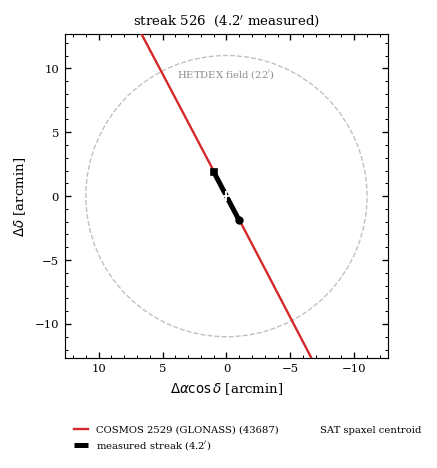

In [18]:
match = Table.read(TRIAL_OUT, hdu="MATCH")
cand  = Table.read(TRIAL_OUT, hdu="CANDIDATES")
matched_ids = match["streak_id"][match["matched"]]
print(f"{len(matched_ids)} matched streaks available")

if len(matched_ids):
    SID = int(matched_ids[min(10, len(matched_ids) - 1)])
    row = info[info["streak_id"] == SID][0]
    streak = {k: (row[k].item() if hasattr(row[k], "item") else row[k])
              for k in M.NEEDED_COLS}
    shot_rows = [{k: (r[k].item() if hasattr(r[k], "item") else r[k])
                  for k in M.NEEDED_COLS}
                 for r in info[info["shotid"] == row["shotid"]]]
    nid = int(F.night_id(row["mjd_shot"]))
    records = M.load_3le(M.find_night_files(CACHE_DIR)[nid])
    norads = [int(n) for n in cand["norad_id"][cand["streak_id"] == SID]]
    tracks = M.shot_tracks(shot_rows, records, site, cfg, norads=norads)
    best = int(match["norad_id"][match["streak_id"] == SID][0])

    fig = P.plot_streak_match(streak, tracks, best_norad=best)
    print("saved:", P.save(fig, f"streak_{SID}_match"))

    m = match[match["streak_id"] == SID][0]
    print(f"\n{m['object_name']} ({m['norad_id']}), {m['constellation']}, "
          f"{m['orbit_class']}")
    print(f"  perp {m['match_perp_arcsec']:.0f}\", "
          f"|dPA| {m['match_pa_diff_deg']:.2f} deg, dt {m['crossing_dt_s']:.0f} s")
    print(f"  range {m['range_km']:.0f} km, height {m['sat_height_km']:.0f} km, "
          f"rate {m['ang_rate_arcsec_s']:.0f} \"/s")
    print(f"  {m['illum_label']}, phase {m['phase_angle_deg']:.0f} deg, "
          f"TLE age {m['tle_age_hours']:+.1f} h")
else:
    print("nothing matched yet -- work through 3b and 3c first")

saved: trend_plots/match_grid.png


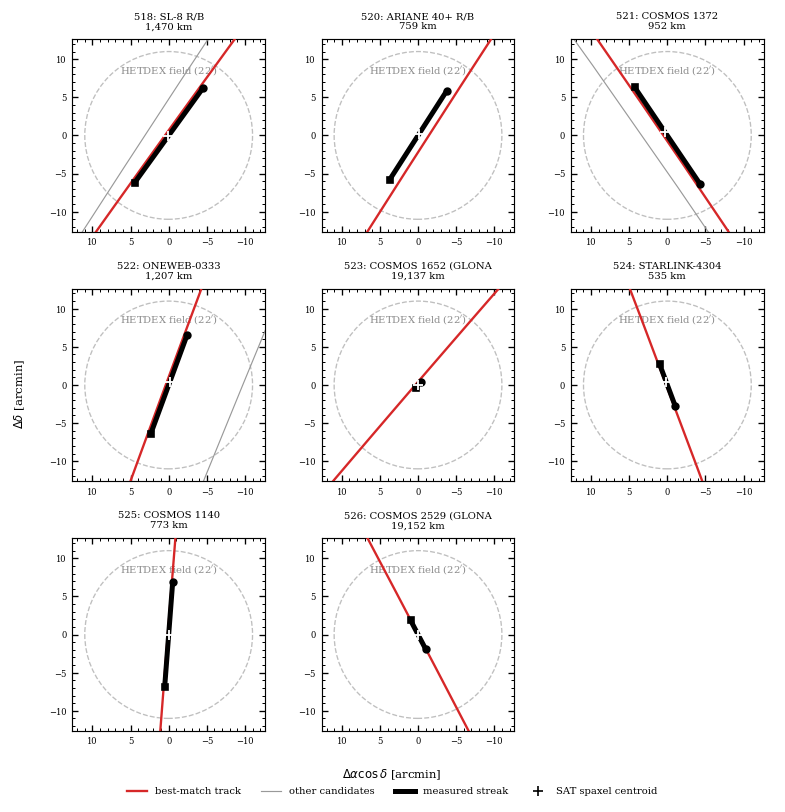

In [19]:
sel = match[match["matched"]]
sids = [int(s) for s in sel["streak_id"][:9]]

entries = M.gather_for_plot(sids, info, match, cand, CACHE_DIR, site, cfg)
fig = P.plot_match_grid(entries)
print("saved:", P.save(fig, "match_grid"))

## 4b. Parallelism

Split over nights: independent, similar sizes, balances well. `n_jobs=-1` uses
every core. Peak memory per worker is set by `cfg.sat_chunk`, not the catalog
size. Pass `CACHE_DIR` rather than a loaded satcat dict — joblib pickles every
argument once per task.

The download is deliberately serial: Space-Track rate-limits per account.

In [20]:
import multiprocessing as mp
N_CORES = mp.cpu_count()
N_JOBS = max(1, N_CORES - 2)
print(f"{N_CORES} cores detected, using n_jobs = {N_JOBS}")

nt = (cfg.margin_before_s + cfg.exposure_span_s + cfg.margin_after_s) / cfg.coarse_step_s
est = cfg.sat_chunk * nt * 120 / 1e6
print(f"estimated coarse-pass memory: {est:.0f} MB/worker, "
      f"{est * N_JOBS:.0f} MB total (lower cfg.sat_chunk if tight)")

12 cores detected, using n_jobs = 10
estimated coarse-pass memory: 35 MB/worker, 346 MB total (lower cfg.sat_chunk if tight)


## 5. Full run

Guards default to `False` so Restart & Run All cannot start a 2 h download.

In [21]:
# The fetch is incremental, so this is driven by the coverage check rather than
# a manual flag: it runs only if nights are actually missing.
if coverage["n_missing"]:
    print(f"{coverage['n_missing']} nights missing "
          f"(~{coverage['n_missing']/280:.1f} h) - fetching")
    F.main(["--catalog", CATALOG, "--cache-dir", CACHE_DIR])
    coverage = M.cache_coverage(info, CACHE_DIR)
else:
    print("cache complete - nothing to fetch")

cache complete - nothing to fetch


In [22]:
FORCE_MATCH = True      # True to re-run the full match (then also re-run §5a + §5b)

### 5a. Identification provenance

Records which pipeline identified each streak, so a SatChecker-derived match is
never mistaken for one this matcher made. Section 5b sets `satchecker` on the
rows it patches; everything else stays `spacetrack`.

Without this the two methods are indistinguishable downstream, and the
cross-check above stops being independent of the catalog it validates.

In [23]:
from astropy.io import fits as _fits

match = Table.read(OUT, hdu="MATCH")
if "id_source" not in match.colnames:
    match["id_source"] = np.where(np.asarray(match["matched"], bool),
                                  "spacetrack", "").astype("U12")
    with _fits.open(OUT, mode="update") as hdul:
        hdu = _fits.table_to_hdu(match); hdu.name = "MATCH"
        for k, h in enumerate(hdul):
            if h.name == "MATCH":
                hdul[k] = hdu
                break
        hdul.flush()
    print(f"added id_source to {OUT}")

vals, cnts = np.unique(match["id_source"], return_counts=True)
for v, c in zip(vals, cnts):
    print(f"  {v or '(unmatched)':>12}: {c}")

FileNotFoundError: [Errno 2] No such file or directory: 'HETDEX_PDR1_sats_matched.fits'

## 5b. SatChecker: identify and integrate missing streaks

Independent check using the IAU CPS SatChecker API (cite [arXiv:2408.16026](https://arxiv.org/abs/2408.16026)).
SatChecker runs its own TLE archive and SGP4 propagation server-side, so
agreement is a genuine end-to-end cross-check.

Here it is used *offensively*: querying the **unmatched, searched** streaks
(`n_propagated > 0`, no Space-Track candidate) to find satellites whose
element sets happened to be absent from our TLE cache for that exact night.
SatChecker's archive fills the gap; `rematch_by_norad` then re-runs our own
pipeline for those pairs to produce residuals and geometry on the same scale
as the Space-Track matches before they are written into the catalog.

In [ ]:
RUN_UNMATCHED = True

set RUN_UNMATCHED = True to query SatChecker for the unmatched streaks


In [ ]:
audit = M.audit_tle_cache(CACHE_DIR, full_scan=True)
match = Table.read(OUT, hdu="MATCH")
info_nights = np.array([int(F.night_id(m)) for m in info["mjd_shot"]])

counts = np.array([audit["counts"].get(n, np.nan) for n in info_nights], float)
matched = np.asarray(match["matched"], bool)
low = counts < 0.5 * audit["median_n_objects"]

print(f"low-count nights:  {matched[low].mean()*100:.1f}% matched  (n={low.sum()})")
print(f"normal nights:     {matched[~low].mean()*100:.1f}% matched  (n={(~low).sum()})")

370 cached nights, 1326.5 MB total, median 3594.8 KB/night
  7 nights flagged on file size (< 2000 B or < 50% of median):
    60146  gp_60146_2023-07-22.3le.gz  645.1 KB
    57833  gp_57833_2017-03-22.3le.gz  1305.2 KB
    60145  gp_60145_2023-07-21.3le.gz  1457.4 KB
    58705  gp_58705_2019-08-11.3le.gz  1502.3 KB
    58992  gp_58992_2020-05-24.3le.gz  1554.8 KB
    60148  gp_60148_2023-07-24.3le.gz  1687.0 KB
    60136  gp_60136_2023-07-12.3le.gz  1770.1 KB



full scan: median 89118 element sets/night
  53 nights flagged on object count (0, or < 50% of median):
    60146  gp_60146_2023-07-22.3le.gz  11738 objects
    57833  gp_57833_2017-03-22.3le.gz  25410 objects
    60145  gp_60145_2023-07-21.3le.gz  27703 objects
    58705  gp_58705_2019-08-11.3le.gz  31332 objects
    60148  gp_60148_2023-07-24.3le.gz  31665 objects
    58992  gp_58992_2020-05-24.3le.gz  32439 objects
    60136  gp_60136_2023-07-12.3le.gz  33941 objects
    60137  gp_60137_2023-07-13.3le.gz  34990 objects
    60143  gp_60143_2023-07-19.3le.gz  35883 objects
    58582  gp_58582_2019-04-10.3le.gz  38103 objects
    58694  gp_58694_2019-07-31.3le.gz  38144 objects
    60140  gp_60140_2023-07-16.3le.gz  38222 objects
    60134  gp_60134_2023-07-10.3le.gz  38606 objects
    60174  gp_60174_2023-08-19.3le.gz  38983 objects
    60177  gp_60177_2023-08-22.3le.gz  39034 objects
low-count nights:  86.5% matched  (n=74)
normal nights:     82.6% matched  (n=453)


In [ ]:
import os
if not os.path.exists("satchecker_unmatched.csv"):
    print("satchecker_unmatched.csv not found - set RUN_UNMATCHED = True first")
else:
    import pandas as pd
    
    chk_un = pd.read_csv("satchecker_unmatched.csv")
    found = chk_un[chk_un["verdict"] == "found"]
    not_found = chk_un[chk_un["verdict"] == "not-found"]
    
    print(f"SatChecker queried : {len(chk_un)}")
    print(f"  found            : {len(found)}  ({100*len(found)/max(len(chk_un),1):.0f}%)")
    print(f"  not found        : {len(not_found)}")
    print()
    if len(found):
        print("Identified by SatChecker:")
        print(found[["streak_id", "satchecker_norad", "satchecker_name",
                     "satchecker_perp_arcsec", "satchecker_pa_diff_deg",
                     "satchecker_n_returned"]].to_string(index=False))

SatChecker queried : 78
  found            : 11  (14%)
  not found        : 67

Identified by SatChecker:


 streak_id  satchecker_norad      satchecker_name  satchecker_perp_arcsec  satchecker_pa_diff_deg  satchecker_n_returned
       400             53200        STARLINK-4417               80.990869                0.262273                     18
       402             48988          ONEWEB-0270               16.851624                0.054347                     12
       481             15227        TITAN 34B R/B               37.599554                0.119219                     20
       243             23401         SL-12 R/B(2)              507.528207                1.704279                     20
       490              9880         MOLNIYA 1-36               52.792914                0.023282                     23
       118             44795             YZ-1 R/B               16.926283                0.178524                     16
       288             44909        BREEZE-KM R/B               21.794778                0.081393                     11
       475             45854 NAV

### Integrate SatChecker-found matches into the catalog

`rematch_by_norad` re-runs our SGP4 fine-pass scorer for each found pair,
bypassing the coarse spatial filter that caused the original miss.  When the
exact night's TLE file lacks the NORAD (common — some objects have sparse
archival coverage), it falls back to the nearest available night within
30 days.  Results are written into `HETDEX_PDR1_sats_matched.fits` before
any downstream analysis runs.

In [ ]:
import os
if not os.path.exists("satchecker_unmatched.csv"):
    print("satchecker_unmatched.csv not found - set RUN_UNMATCHED = True first")
else:
    import importlib
    importlib.reload(M)
    
    from astropy.io import fits as _fits
    
    chk_un = pd.read_csv("satchecker_unmatched.csv")
    found  = chk_un[chk_un["verdict"] == "found"]
    pairs  = list(zip(found["streak_id"].astype(int),
                      found["satchecker_norad"].astype(int)))
    print(f"{len(pairs)} SatChecker-found streaks to rematch: "
          f"{[s for s,_ in pairs]}")
    
    # -- re-run our own SGP4 fine pass for each pair
    new_results = M.rematch_by_norad(pairs, info, CACHE_DIR, site, cfg)
    print(f"\n{len(new_results)} results returned")
    
    # -- patch the MATCH table in memory
    match_upd = Table.read(OUT, hdu="MATCH")
    
    _PACK_COLS = [
        "norad_id", "object_name", "object_id", "object_type", "country",
        "launch_date", "rcs_size", "constellation", "orbit_class", "illum_label",
        "match_perp_arcsec", "match_sep_arcsec", "match_pa_diff_deg",
        "match_end_a_arcsec", "match_end_b_arcsec", "match_score",
        "model_pa_deg", "streak_pa_sph_deg", "crossing_dt_s",
        "tle_age_hours", "range_km", "sat_height_km", "alt_deg",
        "sun_alt_deg", "phase_angle_deg", "ang_rate_arcsec_s",
        "ang_rate_deg_s", "t_cross_s", "g_mag_inst", "g_mag_inst_550km",
        "perigee_km", "apogee_km", "inclination_deg", "eccentricity",
        "period_min", "second_score", "score_margin", "match_time_offset_s",
        "crossing_mjd", "tle_epoch_mjd",
        "n_propagated", "n_close", "n_candidates", "illum_state", "second_norad",
        "unambiguous", "at_window_edge",
    ]
    
    if "id_source" not in match_upd.colnames:
        match_upd["id_source"] = np.where(
            np.asarray(match_upd["matched"], bool), "spacetrack", "").astype("U12")

    streak_ids = np.asarray(match_upd["streak_id"], dtype=int)
    for res in new_results:
        sid  = int(res["streak_id"])
        idxs = np.where(streak_ids == sid)[0]
        if len(idxs) == 0:
            print(f"  WARNING: streak {sid} not in MATCH table — skipped")
            continue
        i = idxs[0]
        for col in _PACK_COLS:
            if col not in match_upd.colnames or col not in res:
                continue
            try:
                match_upd[col][i] = res[col]
            except (TypeError, ValueError) as e:
                print(f"  could not set {col} for streak {sid}: {e}")
        match_upd["matched"][i] = int(res.get("norad_id", -1)) > 0
        if "id_source" in match_upd.colnames:
            match_upd["id_source"][i] = "satchecker"   # provenance
    
    # -- rewrite the FITS file, keeping INFO and CANDIDATES HDUs intact
    with _fits.open(OUT, mode="update") as hdul:
        new_hdu = _fits.table_to_hdu(match_upd)
        new_hdu.name = "MATCH"
        for k, h in enumerate(hdul):
            if h.name == "MATCH":
                hdul[k] = new_hdu
                break
        hdul.flush()
    
    # reload so downstream cells see the updated table
    match = Table.read(OUT, hdu="MATCH")
    print(f"\nWrote updated {OUT}")
    M.summarise(match)

11 SatChecker-found streaks to rematch: [400, 402, 481, 243, 490, 118, 288, 475, 403, 389, 461]


  streak 400: no element set for norad 53200 on night 60141 (not in the per-night cache; no supplemental fetch found either -- try fetch_tles.fetch_missing_norads([(53200, 60142.171875)], CACHE_DIR) first), skipped
  streak 402: no element set for norad 48988 on night 60141 (not in the per-night cache; no supplemental fetch found either -- try fetch_tles.fetch_missing_norads([(48988, 60142.203125)], CACHE_DIR) first), skipped


  streak 481: norad 15227 -> perp 30.8"  dPA 0.12 deg


  streak 243: norad 23401 -> perp 509.1"  dPA 1.71 deg


  streak 490: norad 9880 -> perp 52.8"  dPA 0.02 deg


...

  streak 288: norad 44909 -> perp 14.9"  dPA 0.03 deg


  streak 475: norad 45854 -> perp 2.8"  dPA 0.02 deg
  streak 403: no element set for norad 54676 on night 60141 (not in the per-night cache; no supplemental fetch found either -- try fetch_tles.fetch_missing_norads([(54676, 60142.234375)], CACHE_DIR) first), skipped


  streak 389: norad 54154 -> perp 19.1"  dPA 0.50 deg


  streak 461: norad 39989 -> perp 508.8"  dPA 0.14 deg

8/11 pairs scored

8 results returned

Wrote updated HETDEX_PDR1_sats_matched.fits
matched 446/527 streaks (84.6%); 440 unambiguous
  median |perp| = 14.1"
  median |dPA|  = 0.08 deg
  crossing time rel. mjd_shot: median 403s, 16-84% 138 to 991s
  in umbra (impossible -> false positives): 8
           Other: 317
          Cosmos: 47
        Starlink: 32
          OneWeb: 21
      Globalstar: 13
        GPS/GNSS: 8
          Yaogan: 4
    Iridium-NEXT: 2
         Orbcomm: 1
    Planet/Flock: 1


/opt/conda/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)
/opt/conda/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4842: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  arr.partition(


In [ ]:
# §5b complete — verify the merged catalog
match = Table.read(OUT, hdu="MATCH")
_src = np.array([s.decode() if isinstance(s, bytes) else str(s)
                 for s in match["id_source"]])
_matched = np.asarray(match["matched"], bool)
print(f"Total streaks  : {len(match)}")
print(f"Matched        : {_matched.sum()}  ({100*_matched.mean():.1f}%)")
print(f"  space-track  : {((_src == 'spacetrack') & _matched).sum()}")
print(f"  satchecker   : {((_src == 'satchecker') & _matched).sum()}")
print(f"Unmatched      : {(~_matched).sum()}")
assert _matched.sum() > 438, "SatChecker patches missing — re-run §5b"

Total streaks  : 527
Matched        : 446  (84.6%)
  space-track  : 438
  satchecker   : 8
Unmatched      : 81


### Archived diagnostic — targeted TLE refetch (do not run)

This cell was used during development to delete and re-fetch specific nights
with `--pad-days 30`.  It caused two problems documented in CLAUDE.md (Gotcha 7):

1. Space-Track returned HTTP 204 (zero records) for the wide-window queries on
   five nights, and the original code wrote those empty responses to disk,
   permanently masking the narrower data that had been there before.
2. Five other nights hit the 500 000-record API cap and came back truncated.

The cell is preserved here only so the history is readable. **Do not run it.**
Use `fetch_tles.fetch_missing_norads` for targeted per-NORAD supplemental fetches.

## 6. Check the crossing times

`mjd_shot` is the start of a 22-minute shot, so `crossing_dt_s` should spread
across roughly 0-1320 s. Piling up against either edge means the window is
still wrong; a flat spread over a much wider range would suggest chance matches
rather than real ones.

440 confident matches


saved: trend_plots/crossing_times.png
crossing_dt_s percentiles [0,16,50,84,100]: crossing_dt_s
-------------
        -58.0
        139.6
        402.8
        990.4
       1376.0
expected: inside 0-1320 s, no pile-up at the edges


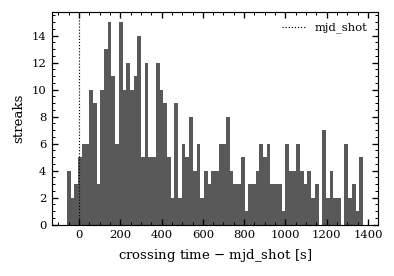

In [ ]:
match = Table.read(OUT if os.path.exists(OUT) else TRIAL_OUT, hdu="MATCH")
good = match[match["matched"] & match["unambiguous"]]
print(f"{len(good)} confident matches")

if len(good):
    fig = P.plot_crossing_times(good["crossing_dt_s"], exptime=None)
    print("saved:", P.save(fig, "crossing_times"))
    q = np.percentile(good["crossing_dt_s"], [0, 16, 50, 84, 100])
    print("crossing_dt_s percentiles [0,16,50,84,100]:", np.round(q, 1))
    print("expected: inside 0-1320 s, no pile-up at the edges")

## 6b. Assess the result

Residual percentiles, purity, timing, object-type mix, and a profile of what
was missed -- plus tolerance recommendations derived from your own residuals
rather than guessed.

In [ ]:
m = M.assess(match, info=info, exposure_span_s=cfg.exposure_span_s)

matched 446/527 (84.6%), 440 unambiguous

residual percentiles (50 / 90 / 99 / max):
  match_perp_arcsec       14.12    74.06   467.26   783.69"
  match_pa_diff_deg        0.08     0.69     4.17     5.73 deg

  suggested second-pass cuts (10x median, robust to the tail):
    max_perp_arcsec = 141    max_pa_deg = 0.81
    would retain 88.1% of current matches
  chance coincidences scale with max_perp x max_pa, so this is a 47x reduction in chance area relative to the 900"/6deg defaults



purity: 8/446 matches in Earth's shadow (1.8% false-positive floor)
  false positives to inspect: [32, 82, 83, 149, 358, 362, 407, 417]

crossing time within the 1320 s shot:
  min -58  16% 138  median 403  84% 991  max 1376 s
  67% fall in the first half (50% would mean uniform across the shot)

object type (the 'Other' constellation bucket is mostly debris and spent stages):
         PAYLOAD:  241   54.0%
     ROCKET BODY:  158   35.4%
          DEBRIS:   47   10.5%

81 unmatched streaks:
  g_mag            median     16.43  (all streaks:     16.37)
  seg_len_arcsec   median    666.70  (all streaks:    665.99)
  mjd_shot         median  59671.25  (all streaks:  59698.14)
  faint or short streaks are the usual cause; an uncatalogued object is the other


Residuals far inside the tolerances mean the matches are real: chance
coincidences would scatter up against the cut, not sit two orders of magnitude
inside it. Take the suggested cuts and re-run for a cleaner sample:

```python
cfg_tight = MatchConfig(**{**vars(cfg),
                           "max_perp_arcsec": 200.0, "max_pa_deg": 1.5})
jobs = M.build_jobs(info, CACHE_DIR, cached_only=True)
results = M.run_all(jobs, site, cfg_tight, CACHE_DIR, n_jobs=N_JOBS)
match = M.write_output(OUT, info, results, cfg_tight, CATALOG)
M.assess(match, info=info)
```

Almost every real match should survive. Anything that drops out was marginal.

In [ ]:
M.audit_false_positives(m, exposure_span_s=cfg.exposure_span_s,
                        margin_before_s=cfg.margin_before_s,
                        margin_after_s=cfg.margin_after_s)

446 matches: 429 during the exposure, 17 outside the shutter
  margin sampled: 100 s   exposure: 1320 s

  chance-match rate      : 612.0 per hour of search
  expected chance matches inside the exposure: 224.4 +/- 54.4  (Poisson on 17 margin counts)
  implied purity         : 48% (205 of 429 genuine)
  -> LOW. Tighten max_perp_arcsec / max_pa_deg and re-run; chance matches scale with the tolerance area.

  median properties (impossible vs plausible):
     outside shutter: n= 17     12.4"    0.09deg      1483km      783"/s
     during exposure: n=429     14.1"    0.08deg      8278km       84"/s
  a distinct population outside the shutter -- typically slow, distant objects -- 
  is the signature of chance alignment, and tells you which cut will remove it


{'n_inside': 429,
 'n_outside': 17,
 'rate_per_s': 0.17,
 'expected_chance': 224.4}

## 7. Match quality

The right panel is a free purity check: **a streak in the umbra is physically
impossible**, so any such match is a false positive.

saved: trend_plots/match_residuals.png

8/446 matches in umbra (1.8% false-positive floor)
6 ambiguous -- inspect with section 4
[np.int32(17), np.int32(18), np.int32(157), np.int32(289), np.int32(417), np.int32(434)]


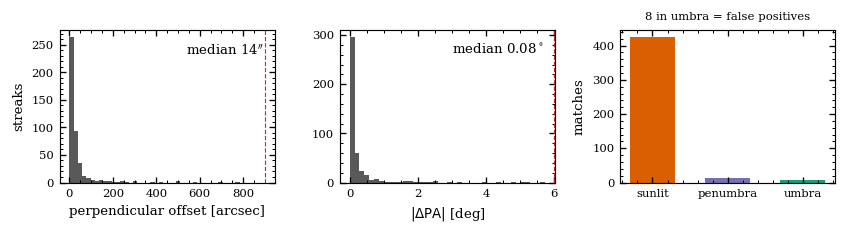

In [ ]:
m = match[match["matched"]]
if len(m):
    fig = P.plot_residuals(m["match_perp_arcsec"], m["match_pa_diff_deg"],
                           m["illum_state"], max_perp=cfg.max_perp_arcsec,
                           max_pa=cfg.max_pa_deg)
    print("saved:", P.save(fig, "match_residuals"))
    n_umbra = int((m["illum_state"] == 0).sum())
    print(f"\n{n_umbra}/{len(m)} matches in umbra "
          f"({100.0 * n_umbra / len(m):.1f}% false-positive floor)")
    amb = m[~m["unambiguous"]]
    print(f"{len(amb)} ambiguous -- inspect with section 4")
    if len(amb):
        print(list(amb["streak_id"][:20]))

## 10. Join the identifications back onto the catalog

In [ ]:
assert np.array_equal(np.asarray(info["streak_id"]),
                      np.asarray(match["streak_id"])), "row order mismatch"
drop = {"streak_id", "shotid"}
full = hstack([info, match[[c for c in match.colnames if c not in drop]]])
full.write(JOINED_OUT, overwrite=True)
print(f"wrote {JOINED_OUT}: {len(full)} rows x {len(full.colnames)} columns")
print(f"{int(match['matched'].sum())} identified")

wrote HETDEX_PDR1_sats_with_ids.fits: 527 rows x 70 columns
446 identified


## 11. Final publication table

Writes three output files covering **all 527 streaks**:

| file | format |
|---|---|
| `HETDEX_PDR1_satellites.fits` | FITS: `SATS` identification table + `WAVE` / `SPECTRA` / `ERRORS` image HDUs copied from the streak catalog |
| `HETDEX_PDR1_satellites.txt`  | AAS machine-readable text (MRT) |
| `HETDEX_PDR1_satellites.csv`  | plain CSV |

Identification columns are **masked** (blank in MRT/CSV, FITS null) for the
~17% of unmatched rows — no sentinel values like `-1`.

# ---------------------------------------------------------------------------
# 11a. Write the main identification table (FITS + MRT + CSV) — all 527 streaks
# ---------------------------------------------------------------------------
if not any(c[1] == "id_source" for c in M.PUB_COLUMNS):
    M.PUB_COLUMNS.append(("M", "id_source", "IDsrc", "",
                          "Source of the identification: spacetrack or satchecker"))

pub = M.write_publication_table(
    CATALOG, OUT if os.path.exists(OUT) else TRIAL_OUT,
    out_base="HETDEX_PDR1_satellites")

_has_norad = ~pub["NORAD"].mask if hasattr(pub["NORAD"], "mask") else pub["NORAD"] > 0
print(f"Publication table: {len(pub)} streaks "
      f"({int(_has_norad.sum())} identified, {int((~_has_norad).sum())} unmatched)")

# ---------------------------------------------------------------------------
# 11b. Append WAVE / SPECTRA / ERRORS from the streak catalog
#      These are already in CATALOG — just copy them into the publication FITS.
# ---------------------------------------------------------------------------
from astropy.io import fits as _fits

out_fits = "HETDEX_PDR1_satellites.fits"

with _fits.open(CATALOG) as ch, _fits.open(out_fits, mode="update") as hdul:
    existing = {h.name for h in hdul}
    for name in ["WAVE", "SPECTRA", "ERRORS"]:
        if name in [h.name for h in ch]:
            if name in existing:
                del hdul[hdul.index_of(name)]
            hdul.append(_fits.ImageHDU(ch[name].data, name=name))
    hdul.flush()

print(f"Spectra HDUs (WAVE / SPECTRA / ERRORS) copied from {CATALOG}")

In [ ]:
# Spot-check: a few identified rows and a few unidentified
show = [c for c in ["ID", "MJD", "RAcen", "DEcen", "Length",
                    "NORAD", "Name", "Class", "Resid", "Height", "IDsrc"]
        if c in pub.colnames]
idx = list(np.where(~pub["NORAD"].mask)[0][:4]) + \
      list(np.where(pub["NORAD"].mask)[0][:2])
pub[show][idx].pprint_all()

 ID      MJD             RAcen                DEcen               Length       NORAD          Name          Class       Resid              Height         IDsrc   
          d               deg                  deg                arcsec                                                arcsec               km                   
--- -------------- ------------------ --------------------- ------------------ ----- ---------------------- ----- ------------------ ------------------ ----------
  2    58075.09375  7.094703197479248   0.04804031178355217 56.511383056640625 33509 TITAN 3C TRANSTAGE DEB   GEO  3.514914515426426  35073.07627571971 spacetrack
  3 58108.12890625 19.245155334472656  -0.04213857650756836  63.21871566772461 39362    BREEZE-M DEB (TANK)   HEO 143.61767466718334  6502.327122805319 spacetrack
  4     58216.1875 200.56573486328125    51.212581634521484 336.95355224609375 39524    BREEZE-M DEB (TANK)   HEO  32.12114874797294 21856.876089397676 spacetrack
  5 58219.13671875  18

In [ ]:
# Confirm the three output files exist and their sizes
for fname in ["HETDEX_PDR1_satellites.fits",
              "HETDEX_PDR1_satellites.txt",
              "HETDEX_PDR1_satellites.csv"]:
    if os.path.exists(fname):
        sz = os.path.getsize(fname) / 1e6
        print(f"  {fname}  ({sz:.1f} MB)")
    else:
        print(f"  MISSING: {fname}")

  HETDEX_PDR1_satellites.fits  (0.2 MB)
  HETDEX_PDR1_satellites.txt  (0.4 MB)
  HETDEX_PDR1_satellites.csv  (0.3 MB)


## Done

**Run order for a clean final run (Restart & Run All):**

1. §0 — config + imports  
2. §0b — unit tests (must pass before continuing)  
3. §1 / §1b — catalog inspection + TLE cache audit  
4. §2 — fetch any missing TLE nights (incremental, skips cached)  
5. §3 — trial match on the 5 most recent cached nights  
6. §3b.i — SatChecker cross-check on the **matched** sample (must run before §5b)  
7. §4 — inspect individual streaks  
8. §5 — full match (guard prevents overwriting SatChecker patches)  
9. §5a — stamp `id_source = spacetrack`  
10. §5b — SatChecker integration for unmatched streaks  
11. §5b verification cell — asserts matched count > 438  
12. §6 / §6b / §7 — diagnostics  
13. §10 — joined working file  
14. §11 — final publication table (set `SPECTRA_FITS` / `SPECTRA_CSV` when ready)

**Space-Track user agreement:** raw element sets may not be redistributed.
Publishing NORAD IDs and derived quantities (residuals, geometry) is permitted.

In [98]:
from astropy.io import fits

In [99]:
hdu = fits.open('HETDEX_PDR1_satellites.fits')

In [100]:
hdu.info()

Filename: HETDEX_PDR1_satellites.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU    219   527R x 43C   [J, K, D, D, D, D, D, D, D, D, D, D, D, I, D, D, D, J, 24A, 10A, 11A, 4A, 10A, 12A, 3A, D, D, I, D, D, D, D, D, D, D, 8A, D, D, D, D, D, D, 10A]   
